In [ ]:
import re
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report , f1_score

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/dataset.csv"

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df = df.dropna(subset=["text", "label"]).reset_index(drop=True)
df["label"] = df["label"].astype(int)

NUM_CLASSES = df["label"].nunique()
class_names = [str(c) for c in sorted(df["label"].unique())]
print(df["label"].value_counts())
print("Number of classes:", NUM_CLASSES)
df.head()

label
0    377
1    208
2    130
3     28
Name: count, dtype: int64
Number of classes: 4


,text,label
0,Jessica Taylor called the police to report sus...,0
1,Patricia Moore was jogging near a school campu...,0
2,Linda Davis helped a neighbor carry groceries ...,0
3,Ahmed Hassan read a book quietly at a warehous...,0
4,Kevin Thompson was found in possession of ille...,1


In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

print("train:", len(train_df), "val:", len(val_df), "test:", len(test_df))

train: 520 val: 111 test: 112


In [ ]:
BATCH = 16

def make_ds(frame, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((frame["text"].values, frame["label"].values))
    if shuffle:
        ds = ds.shuffle(len(frame), seed=42)
    return ds.batch(BATCH)

train_ds = make_ds(train_df, shuffle=True)
val_ds = make_ds(val_df)
test_ds = make_ds(test_df)

In [ ]:
MAX_TOKENS = 5000
SEQ_LEN = 32

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQ_LEN
)
vectorizer.adapt(train_df["text"].values)

vocab_size = len(vectorizer.get_vocabulary())
print("Vocab size:", vocab_size)

Vocab size: 418


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def vectorize(text, label):
    return vectorizer(text), label

train_ds = train_ds.map(vectorize).prefetch(AUTOTUNE)
val_ds = val_ds.map(vectorize).prefetch(AUTOTUNE)
test_ds = test_ds.map(vectorize).prefetch(AUTOTUNE)

In [ ]:
EMBED_DIM = 64

def build_dense():
    model = tf.keras.Sequential([
        tf.keras.layers.Input((SEQ_LEN,)),
        tf.keras.layers.Embedding(vocab_size, EMBED_DIM),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax"),
    ])
    return model

In [ ]:
def build_conv1d():
    model = tf.keras.Sequential([
        tf.keras.layers.Input((SEQ_LEN,)),
        tf.keras.layers.Embedding(vocab_size, EMBED_DIM),
        tf.keras.layers.Conv1D(64, 3, padding="same", activation="relu"),
        tf.keras.layers.GlobalMaxPooling1D(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax"),
    ])
    return model

In [ ]:
def build_lstm():
    model = tf.keras.Sequential([
        tf.keras.layers.Input((SEQ_LEN,)),
        tf.keras.layers.Embedding(vocab_size, EMBED_DIM),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax"),
    ])
    return model

In [ ]:
def build_bilstm():
    model = tf.keras.Sequential([
        tf.keras.layers.Input((SEQ_LEN,)),
        tf.keras.layers.Embedding(vocab_size, EMBED_DIM),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax"),
    ])
    return model

In [ ]:
models = {
    "Dense": build_dense(),
    "Conv1D": build_conv1d(),
    "LSTM": build_lstm(),
    "BiLSTM": build_bilstm(),
}

from sklearn.utils.class_weight import compute_class_weight

classes = np.array(sorted(df["label"].unique()))
weights = compute_class_weight("balanced", classes=classes, y=train_df["label"].values)
class_weight = dict(zip(classes, weights))

for name, model in models.items():
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

In [ ]:
early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
reduce = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=3, min_lr=1e-6, factor=0.5)
callback = [early, reduce]

histories = {}
for name, model in models.items():
    print(f"\n=== Training {name} ===")
    histories[name] = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        callbacks=callback,
        class_weight=class_weight,
        verbose=1
    )


=== Training Dense ===
Epoch 1/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.4846 - loss: 1.3826 - val_accuracy: 0.6306 - val_loss: 1.3502 - learning_rate: 0.0010
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6519 - loss: 1.3560 - val_accuracy: 0.7387 - val_loss: 1.2919 - learning_rate: 0.0010
Epoch 3/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7788 - loss: 1.2983 - val_accuracy: 0.8198 - val_loss: 1.1578 - learning_rate: 0.0010
Epoch 4/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8423 - loss: 1.1738 - val_accuracy: 0.9820 - val_loss: 1.0202 - learning_rate: 0.0010
Epoch 5/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9308 - loss: 0.9633 - val_accuracy: 0.9910 - val_loss: 0.6951 - learning_rate: 0.0010
Epoch 6/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9654 - loss: 0.7016 - val_accuracy: 0.9910 - val_loss: 0.4749 - learning_rate: 0.0010
Epoch 7/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9712 - loss

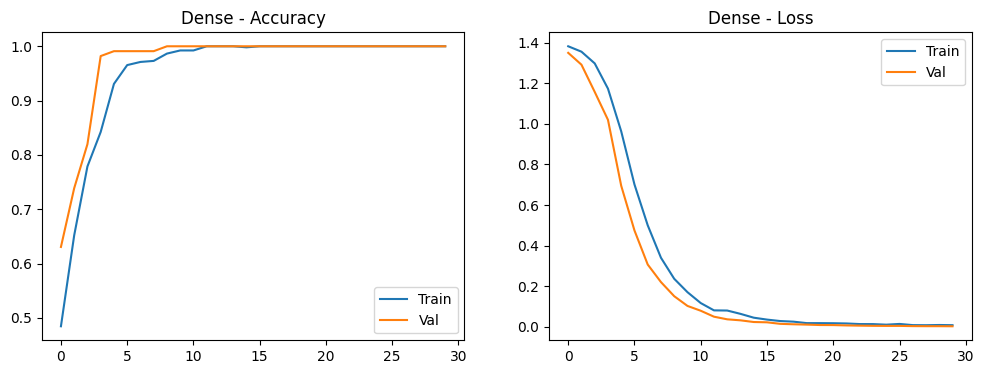

<Figure size 640x480 with 0 Axes>

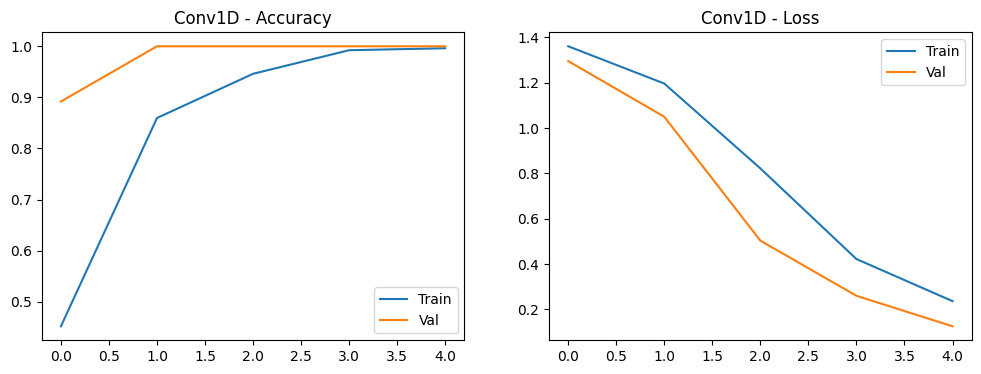

<Figure size 640x480 with 0 Axes>

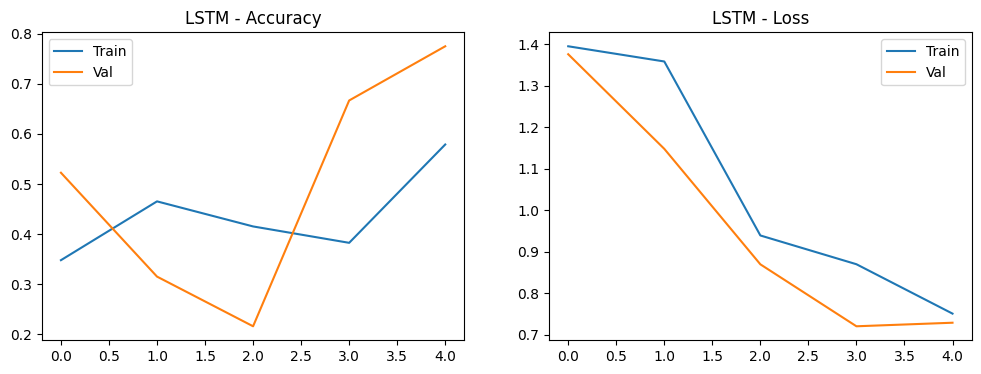

<Figure size 640x480 with 0 Axes>

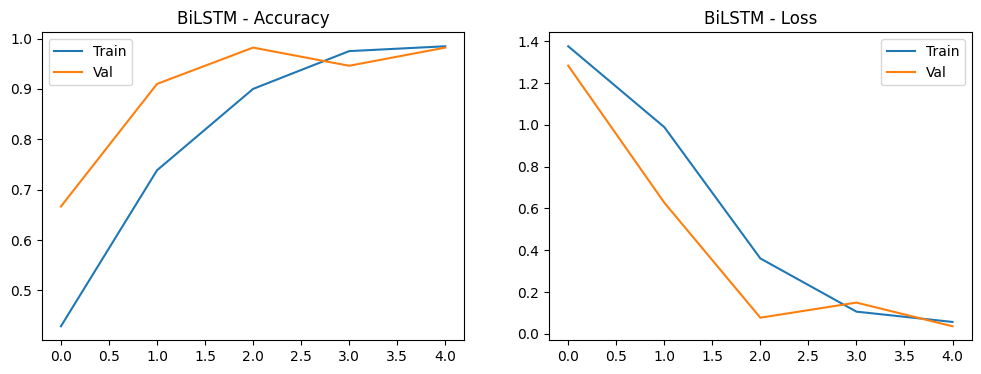

<Figure size 640x480 with 0 Axes>

In [ ]:
for name, his in histories.items():
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(his.history["accuracy"])
    plt.plot(his.history["val_accuracy"])
    plt.title(f"{name} - Accuracy")
    plt.legend(["Train", "Val"])

    plt.subplot(1, 2, 2)
    plt.plot(his.history["loss"])
    plt.plot(his.history["val_loss"])
    plt.title(f"{name} - Loss")
    plt.legend(["Train", "Val"])
    plt.show()
    plt.savefig("model_performance.png")

In [ ]:
y_true = np.concatenate([y.numpy() for x, y in test_ds])

for name, model in models.items():
    y_prob = model.predict(test_ds)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true , y_pred, average="weighted")
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f}  F1: {f1:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}")
    print("Confusion Matrix:\n", cm)
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

=== Dense ===
Accuracy: 1.0000  F1: 1.0000  Precision: 1.0000  Recall: 1.0000
Confusion Matrix:
 [[57  0  0  0]
 [ 0 32  0  0]
 [ 0  0 19  0]
 [ 0  0  0  4]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        57
           1       1.00      1.00      1.00        32
           2       1.00      1.00      1.00        19
           3       1.00      1.00      1.00         4

    accuracy                           1.00       112
   macro avg       1.00      1.00      1.00       112
weighted avg       1.00      1.00      1.00       112

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

=== Conv1D ===
Accuracy: 0.8661  F1: 0.8707  Precision: 0.9017  Recall: 0.8661
Confusion Matrix:
 [[45 12  0  0]
 [ 0 31  1  0]
 [ 0  2 17  0]
 [ 0  0  0  4]]
              precision    recall  f1-score   support

           0       1.00      0.79      0.88        57
           1       0.69      0.97      0.81        32
       

In [ ]:
for name , model in models.items() :
    model.save(f"model_{name}_crime.keras")

In [ ]:
vectorizer.adapt(train_df["text"].values)
vocab_size = len(vectorizer.get_vocabulary())

import pickle
with open("vectorizer_vocab_crime_model.pkl", "wb") as f:
    pickle.dump(vectorizer.get_vocabulary(), f)